# Target, Evaluation Metircs and Baseline

In this notebook we:

* Define our target

* Discuss the evaluation metrics

* Build a Baseline Model


**NOTE:** Before starting exploring this notebook, I recommend checking `1-EDA.ipynb` notebook first - it contains Exploratory Data Analysis of the engines datasets and will help you get some understanding of the datasets. 

---

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

First, let's read the data, we start with "FD001" dataset:

In [8]:
import os
import pandas as pd

def find_data_path():
    current_folder = os.getcwd()
    places_to_look = ['CMAPSSData', '../CMAPSSData', '../data/CMAPSSData']
    
    for place in places_to_look:
        full_path = os.path.abspath(place)
        train_file = os.path.join(full_path, 'train_FD001.txt')
        if os.path.exists(train_file):
            print(f"Found data at: {full_path}")
            return full_path + '/'
    
    print("ERROR: Could not find CMAPSS data!")
    return None

DATA_PATH = find_data_path()
if DATA_PATH is None:
    raise FileNotFoundError("Data not found!")

column_names = ['unit', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + \
               ['sensor_' + str(i) for i in range(1, 22)]

def read_dataset(name='FD001'):
    train_file = DATA_PATH + 'train_' + name + '.txt'
    test_file  = DATA_PATH + 'test_'  + name + '.txt'
    rul_file   = DATA_PATH + 'RUL_'   + name + '.txt'
    
    for f in [train_file, test_file, rul_file]:
        if not os.path.exists(f):
            raise FileNotFoundError(f"Missing file: {f}")
    
    train = pd.read_csv(train_file, sep=r'\s+', header=None, names=column_names, engine='python')
    test  = pd.read_csv(test_file,  sep=r'\s+', header=None, names=column_names, engine='python')
    rul   = pd.read_csv(rul_file,   header=None, names=['rul'])
    
    print(f"Dataset: {name}")
    print(f"Train shape: {train.shape}")
    print(f"Test shape:  {test.shape}")
    print(f"RUL shape:   {rul.shape}")
    
    return train, test, rul

# Read data
train_data, test_data, test_rul = read_dataset('FD001')

Found data at: d:\DEPI\Project Git\Yaqza\notebooks\CMAPSSData
Dataset: FD001
Train shape: (20631, 26)
Test shape:  (13096, 26)
RUL shape:   (100, 1)


In [10]:
# Define the function first
def add_rul_to_train_fast(train_df):
    """
    Add RUL column using vectorized operations (faster).
    """
    df = train_df.copy()
    
    # Step 1: Get last cycle for each engine
    last_cycle = df.groupby('unit')['time_cycles'].transform('max')
    
    # Step 2: Calculate RUL for ALL rows at once
    df['RUL'] = last_cycle - df['time_cycles']
    
    # Step 3: Clip at 125
    df['RUL'] = df['RUL'].clip(upper=125)
    
    return df

# Calculate RUL
train_with_rul = add_rul_to_train_fast(train_data)

# Now show results
print("Last 10 rows of Engine 1 (should show decreasing RUL):")
print(train_with_rul[train_with_rul['unit'] == 1][['unit', 'time_cycles', 'RUL']].tail(10))

print(f"\nEngines with max cycle > 125: {(train_with_rul.groupby('unit')['time_cycles'].max() > 125).sum()}")

Last 10 rows of Engine 1 (should show decreasing RUL):
     unit  time_cycles  RUL
182     1          183    9
183     1          184    8
184     1          185    7
185     1          186    6
186     1          187    5
187     1          188    4
188     1          189    3
189     1          190    2
190     1          191    1
191     1          192    0

Engines with max cycle > 125: 100


# The Target

Our taget will be estimating engines **Remaing Useful Life (RUL):** 

> RUL - remaining time that a component can function with an acceptable performance before it fails. In our case - it's a number of cycles from a current cycle to the engine's end of useful life (last cycle). 

Let's see RUL values for a couple of picked engines:

In [11]:
def calculate_RUL(X, upper_threshold=None):
    '''
    Calculate Remaining Useful Life per engine unit.
    
    Parameters:
    -----------
    X : pd.DataFrame
        Data with 'unit' and 'time_cycles' columns
    upper_threshold : int or None
        Maximum RUL value (clip values above this)
    
    Returns:
    --------
    pd.Series
        RUL values aligned with input index
    '''
    # Get max cycle for each engine (vectorized)
    lifetime = X.groupby('unit')['time_cycles'].transform('max')
    
    # Calculate RUL: max_cycle - current_cycle
    rul = lifetime - X['time_cycles']
    
    # Apply threshold if provided (keep as pandas Series)
    if upper_threshold is not None:
        rul = rul.clip(upper=upper_threshold)
    
    return rul


# Apply to training data with threshold 125
train_data['RUL'] = calculate_RUL(train_data, upper_threshold=125)

# Verify it worked
print("RUL calculated successfully!")
print(f"RUL range: {train_data['RUL'].min()} to {train_data['RUL'].max()}")
print(f"\nFirst 5 rows:")
print(train_data[['unit', 'time_cycles', 'RUL']].head())

print(f"\nLast 5 rows of Engine 1:")
print(train_data[train_data['unit'] == 1][['unit', 'time_cycles', 'RUL']].tail())

RUL calculated successfully!
RUL range: 0 to 125

First 5 rows:
   unit  time_cycles  RUL
0     1            1  125
1     1            2  125
2     1            3  125
3     1            4  125
4     1            5  125

Last 5 rows of Engine 1:
     unit  time_cycles  RUL
187     1          188    4
188     1          189    3
189     1          190    2
190     1          191    1
191     1          192    0


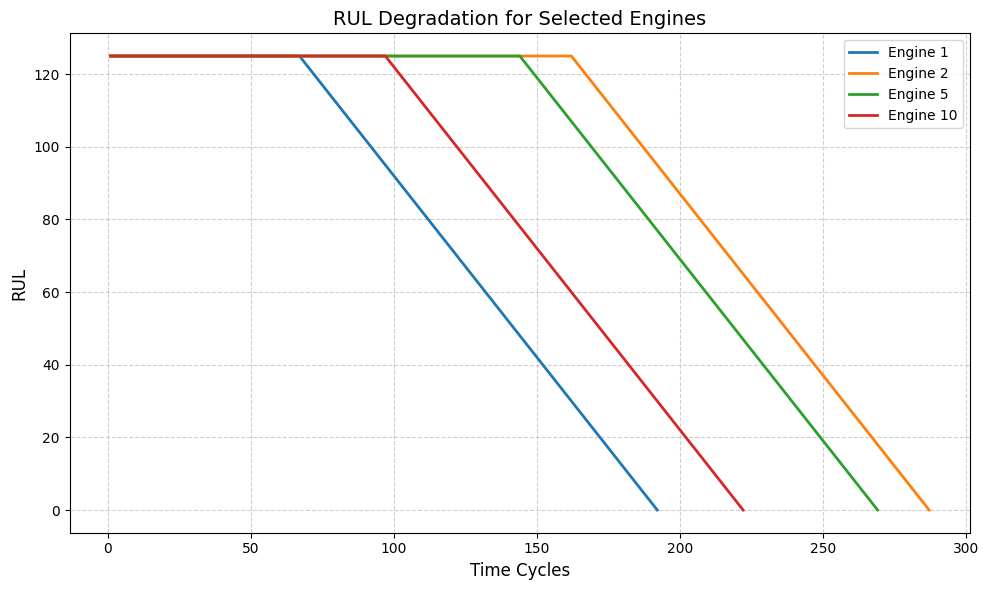

In [12]:
# Plot RUL for selected engines
selected_engines = [1, 2, 5, 10]

fig, ax = plt.subplots(figsize=(10, 6))

for engine_id in selected_engines:
    engine_data = train_data[train_data['unit'] == engine_id]
    ax.plot(
        engine_data['time_cycles'],
        engine_data['RUL'],
        label=f'Engine {engine_id}',
        linewidth=2
    )

ax.set_xlabel('Time Cycles', fontsize=12)
ax.set_ylabel('RUL', fontsize=12)
ax.set_title('RUL Degradation for Selected Engines', fontsize=14)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

And the distributions of RUL values in the Train/Test sets are visualized below:

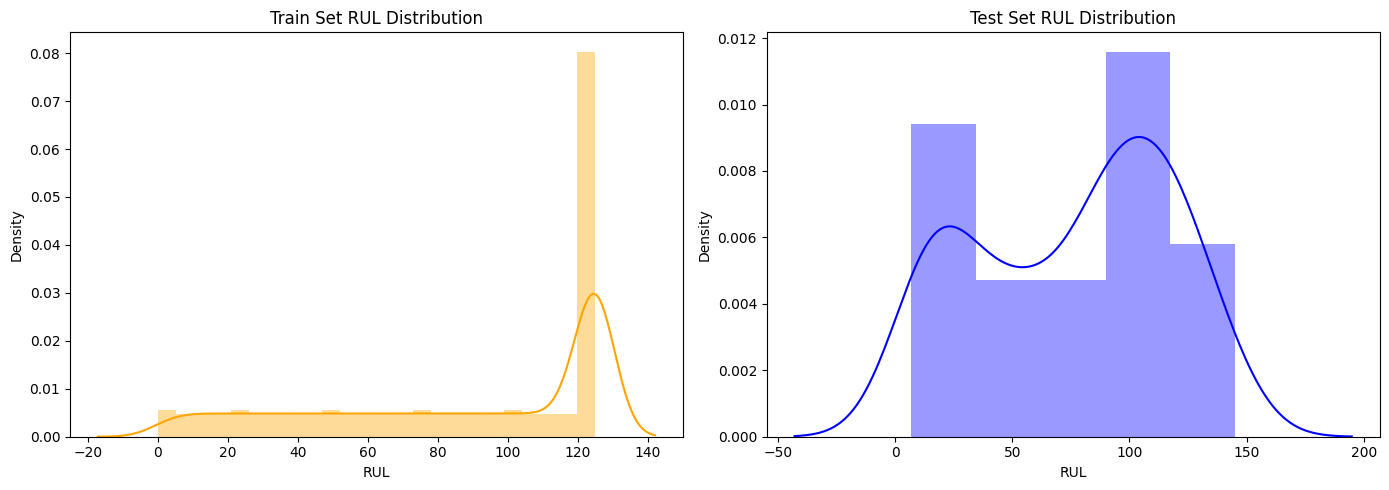

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train RUL
sns.distplot(train_data['RUL'], ax=axes[0], color='orange')
axes[0].set_title('Train Set RUL Distribution')
axes[0].set_xlabel('RUL')
axes[0].set_ylabel('Density')

# Test RUL
sns.distplot(test_rul, ax=axes[1], color='blue')
axes[1].set_title('Test Set RUL Distribution')
axes[1].set_xlabel('RUL')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

As you can see from the figure above, the Train set contains samples with RUL way higher than in the Test set and this is because there're engines full lifetime data in the Train set, and in the Test set there's engines data till some period of time before its end of life. 

In most of the papers related to this problem, maximum value of RUL is being **limited to some constant value**. And the motivation is that a degradatation process will be only noticeable in the data after a unit has operated for some time. You can read more about this in this paper - https://www.researchgate.net/publication/224358896_Recurrent_neural_networks_for_remaining_useful_life_estimation.


So, we are going to **limit a maximum value of RUL with 135** (you can find details about how this specific value was picked in the paper following the link above) - please, see the changed RUL plots below:

In [15]:
RUL_UPPER_THRESHOLD = 135

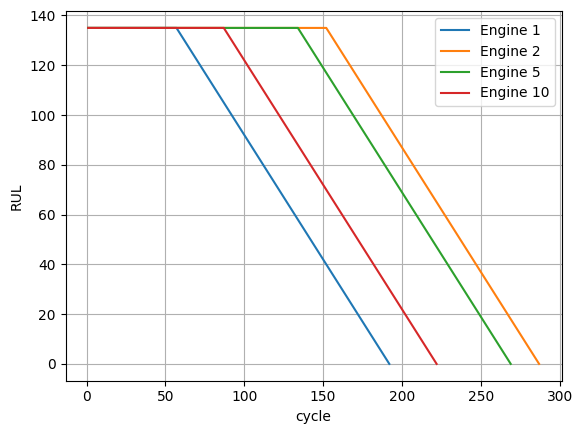

In [16]:
train_data['rul'] = calculate_RUL(train_data, upper_threshold=RUL_UPPER_THRESHOLD)

for _unit in [1, 2, 5, 10]:
    plt.plot(
        train_data[train_data['unit'] == _unit]['time_cycles'], 
        train_data[train_data['unit'] == _unit]['rul'], 
        label=f'Engine {_unit}'
    )
plt.legend()
plt.xlabel('cycle')
plt.ylabel('RUL')
plt.grid()
plt.show()

train_data = train_data.drop(columns=['rul'])

# Evaluation Metrics

We are solving a Regression problem here and let's list and discuss the metrics we can use to evaluate the models for estimating Remaining Useful Life:

1. **RMSE** - Root Mean Squared Error - one of the standard metrics for regression, it's a squared root of averaged squared difference between actual and predicted values. An important characteristic of RMSE is that it penalizes larger errors more. 

$$ RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}{(y_i - \hat{y_i})^2}} $$

2. **MAE** - Mean Absolute Error - an average of absolute difference between actual and predicted values. MAE uses the same scale as the data and it's more robust to outliers.

$$ MAE = \frac{1}{n} \sum_{i=1}^{n}{ |y_i - \hat{y_i}| } $$

3. **MAPE** - Mean Absolute Percentage Error - average ratio of error over actual value, it measures the size of error as a percentage. **NOTE that this metric is not defined for $y=0$**. Also, if the actual values are very small, MAPE can be very high because of that. 
Another interesing characteristic of this metric is that **it's biased towards predictions which are lower than the actual values**. MAPE score will be lower for a prediction lower than the actual value, but it will be higher for a prediction which is higher than the actual value by the same amount, e.g. $ y=1, \hat{y}=2$, then $ MAPE = 100\% $, but when $ y=2, \hat{y}=1 $, then $MAPE=50\%$. 

$$ MAPE = 100 * \frac{1}{n} \sum_{i=1}^{n}{ |\frac{y_i - \hat{y_i}}{y_i}| } $$


4. **Custom Score** - this score is being used in most of the papers about estimating Remaining Useful Life for the turbofan data we use here, provided in Saxena et al. [1]. 

$$ SCORE = \sum_{i=1}^{n}{(e^{-\frac{(y_i - \hat{y_i})}{w}} - 1 ) }, $$

where $ w = 10 $, if $\hat{y} \geq y $
and $ w = 13 $, if $\hat{y} \lt y $

**NOTE that since this metric is a SUM, it cannot be compared across datasets of a different size!** It will be larger for a higher $n$. 

This scoring function assigns a **higher penalty when the Predicted RUL is higher than the true RUL** - please, see the figure below. The motivation for this is that late predictions are potentially more costly - predicting end of engine's life after it actually ended can cause much more problems than predicting it too early. 


[1] A. Saxena, K. Goebel, D. Simon, N. Eklund
Damage propagation modeling for aircraft engine run-to-failure simulation
2008 International Conference on Prognostics and Health Management, IEEE (2008), pp. 1-9


Now let's see how the **Custom score** (Item 4 on the list above) function assigns a higher weight to predictions higher than the actual:

In [17]:
def rul_score_f(err):
    if err >= 0:
        return np.exp(err / 10) - 1
    else:
        return np.exp(- err / 13) - 1


# Why this metric is a sum? Why not average?
# it means the metric increases with the size of the dataset
# and it means that it's not comparable between datasets
# of different sizes
def rul_score(true_rul, estimated_rul):
    err = estimated_rul - true_rul
    return np.sum([rul_score_f(x) for x in err])


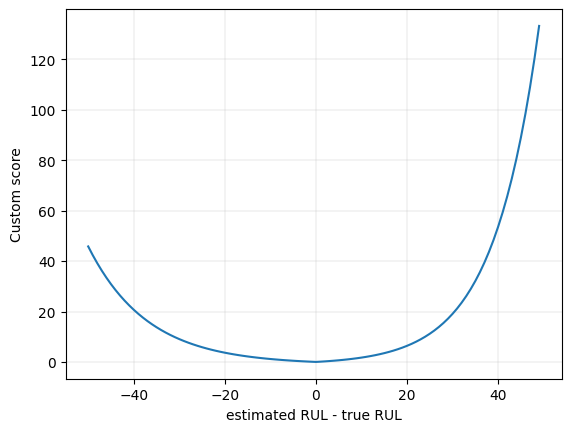

In [18]:
plt.plot(np.arange(-50, 50), 
         [rul_score_f(x) for x in np.arange(-50, 50)])
plt.xlabel('estimated RUL - true RUL')
plt.ylabel('Custom score')
plt.grid(linewidth=0.2)
plt.show()

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error


def rul_metrics_scorer(model, X, true_rul, metrics='all'):
    '''
    Calculate evaluation metrics:
        1. rmse - Root Mean Squared Error
        2. mae - Mean Absolute Error
        3. mape - Mean Absolute Percentage Error
        4. score - Custom metric with higher weight on underestimated RUL

    Returns
    -------
    dict with metrics
    '''
    scores_f = {
        'rmse': lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae': mean_absolute_error,
        'mape': mean_absolute_percentage_error,
        'score': rul_score
    }

    pred_rul = model.predict(X)

    def calculate_scores(metrics_list):
        return {m: scores_f[m](true_rul, pred_rul) for m in metrics_list}

    if metrics == 'all':
        return calculate_scores(scores_f.keys())
    elif isinstance(metrics, list):
        return calculate_scores(metrics)


# Prognostics Performance Evaluation Metrics

Prognostics has different performance requirements than general forecasting applications, which translates into differences in metrics. A couple of prognostics metrics are described in [2]: 


![](figures/prognostics_metrics.png)

*Figure source: [2]*

[2] Saxena, A.; Celaya, J.; Saha, B.; Saha, S.; Goebel, K. Metrics for Offline Evaluation of Prognostic Performance. Int. J. Progn. Health Manag. 2010


<br>
<br>


1. **Prognostic Horizon** - difference between time index when predictions first meet the specified performance criteria, specified in terms of error bounds $\alpha$, and the time index for end of life. It answers how much time it allows for any corrective action to be taken. The choice of error margin depends on time required for corrective action. 


![](figures/prognostic_horizon.png)
*Figure source: [2]*

See the function below:

In [20]:
def prognostic_horizon(pred_rul_dists, true_rul, beta=0.75, alphas=[-7, 7]):
    '''Calculate Prognostic Horizon 
    
    Parameters
    ----------
    pred_rul_dists : list w predicted distributions with method dist.cdf
    true_rul : np.array, ground truth Remaining Useful Life
    beta : float, probability threshold
    alphas : list, error margins
    
    Returns
    -------
    a tuple of prognostic horizon and corresponding probabilities
    '''
    assert len(alphas) == 2, "expect `alphas` to be a list of length 2"
    assert len(pred_rul_dists) == len(true_rul), "expect pred dists and true rul w same len"
    
    prog_horizon = 0
    prob_within_bounds = np.zeros(len(true_rul))
    
    horizon_found = False
    for i in range(len(true_rul)):
        pred_rul_cdfs = []
        for alpha in alphas:
            pred_rul_cdfs.append(
                pred_rul_dists[::-1][i].dist.cdf(np.maximum(true_rul[::-1][i] + alpha, 0)))
        beta_proba = pred_rul_cdfs[1] - pred_rul_cdfs[0]
        prob_within_bounds[::-1][i] = beta_proba
        
        if not horizon_found:
            if beta_proba >= beta:
                prog_horizon = true_rul[::-1][i]
            else:
                horizon_found = True 

    return int(prog_horizon), prob_within_bounds

2. **$\alpha-\lambda$ accuracy** - binary check if prediction at specific time instance $t_{\lambda}$ (fraction of time beetween time index when the first prediction is made and end of life) falls within error bounds ($\alpha$ bounds). Time instance $t_{\lambda}$ can be defined as a fraction of engines lifetime - $\lambda$:

$$t_{\lambda} = t_{0} + \lambda * (t_{EOL} - t_{0}),$$

where
* $t_{EOL}$ engined End Of Life
* $t_{0}$ is a time instance of a first prediction made.


![](figures/alpha_lambda_performance.png)
*Figure source: [2]*

See the function below:

In [21]:
def alpha_lambda_acc(pred_rul_dists, true_rul, time_frac=[0.5, 0.75, 0.9], beta=0.75, alpha=0.1):
    '''Calculate Alpha-Lambda Accuracy
    
    Parameters
    ----------
    pred_rul_dists : list w predicted distributions with method dist.cdf
    true_rul : np.array, ground truth Remaining Useful Life
    time_frac : list of time fractions for predictions
    beta : float, probability threshold
    alpha : float, error margin around actual RUL
    
    Returns
    -------
    a tuple of binary alpha-lambda acc and corresponding probabilities
    '''
    assert len(pred_rul_dists) == len(true_rul), "expect pred dists and true rul w same len"
    
    n_time_inst = len(true_rul)
    
    alha_lambda_acc = np.full(len(time_frac), -1)
    pred_probas = np.full(len(time_frac), -1.0)
    for i, t_frac in enumerate(time_frac):
        t_instance = int(np.round(n_time_inst * t_frac))
        t_inst_true_rul = true_rul[t_instance]
        upper_bound = np.maximum(np.round(t_inst_true_rul * (1 + alpha)), 2)
        low_bound = np.round(t_inst_true_rul * (1 - alpha))
        
        t_inst_pred = pred_rul_dists[t_instance]
        
        pred_probas[i] = t_inst_pred.dist.cdf(upper_bound) - t_inst_pred.dist.cdf(low_bound)
        
        if pred_probas[i] >= beta:
            alha_lambda_acc[i] = 1
        else:
            alha_lambda_acc[i] = 0

    return alha_lambda_acc, pred_probas


3. **Relative Accuracy** - error relative to actual RUL at specific time instance $t_{\lambda}$:

$$RA_{\lambda} = 1 - \frac{RUL error_{\lambda}}{true RUL_{\lambda}}$$

Time instance $t_{\lambda}$ can be defined as a fraction of engines lifetime - $\lambda$:

$$t_{\lambda} = t_{0} + \lambda * (t_{EOL} - t_{0}),$$

where
* $t_{EOL}$ engined End Of Life
* $t_{0}$ is a time instance of a first prediction made.

<br>
See the function below:

In [22]:
def relative_accuracy(pred_rul, true_rul, time_frac=[0.5, 0.75, 0.9]):
    '''Calculate Relative Accuracy
    
    Parameters
    ----------
    pred_rul : np.array, w predicted Remaining Useful Life
    true_rul : np.array, ground truth Remaining Useful Life
    time_frac : list of time fractions for predictions
    
    Returns
    -------
    np.array of relative accuracy at every time instance from `time_frac`
    '''
    assert len(pred_rul) == len(true_rul), "expect predicted and true rul w same length"

    n_time_inst = len(true_rul)

    rel_acc = np.full(len(time_frac), -1.0)
    for i, t_frac in enumerate(time_frac):
        t_instance = int(np.round(n_time_inst * t_frac))
        t_inst_true_rul = true_rul[t_instance]
        t_inst_pred = pred_rul[t_instance]

        rel_acc[i] = 1 - np.abs(t_inst_true_rul - t_inst_pred) / t_inst_true_rul

    return rel_acc

# Baseline Model

We start with a Baseline Model which will be our reference point to which compare all the other models. For instance, a baseline model can be even a random guess, and if a model you developed can't beat such baseline - that's your red flag.

Our Baseline Model will be based on a random sample from engines RUL in the train set. Let's go through the steps it takes:

1. for a given test engine, consider only engines in the train set which lifespan was higher than the current cycle for the test engine
2. estimate Remaining Useful Life as a difference between AVG lifespan of the sampled engines from the train set and the test engine current cycle
3. if there are no engines in the train set with a higher lifespan than the test engine, estimate RUL with a randomly picked integer from [1, 50]

And here's the Baseline Model implemented:

In [23]:
class BaselineModel:
    '''
    Estimate Remaining Useful Life as an Average RUL of 
    engines with longer lifetime.
    
    If there are no older engines in train set, it randomly samples from [0, 50]. 
    '''
    def fit(self, X):
        '''
        Parameters
        ----------
        X : pd.DataFrame, engines data
        '''
        self.lifetime = X.groupby(['unit'])['time_cycles'].max().reset_index(name='last_cycle')
        
    def predict(self, X):
        '''
        Parameters
        ----------
        X : pd.DataFrame, engines data
        '''
        rul = []
        for current_cycle in X['time_cycles'].values:
            lifetime_sample = self.lifetime.loc[
                (self.lifetime['last_cycle'] > current_cycle),
                'last_cycle'
            ]

            if lifetime_sample.shape[0] == 0:
                estimated_rul = np.random.randint(low=1, high=50, size=1)[0]
            else:
                estimated_rul = np.round(lifetime_sample.mean()) - current_cycle

            rul.append(estimated_rul)
        return np.array(rul)


In [24]:
def plot_residuals_vs_actual(actual_rul, predicted_rul,
                             title='Test set - Residuals vs Actual RUL',
                             xlabel='Actual RUL', ylabel='Residuals',
                             ax=None):
    '''A scatter plot of residuals vs '''
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    residual = predicted_rul - actual_rul
    ax.set_title(title)
    sns.regplot(x=actual_rul, y=residual, lowess=True, ax=ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axhline(y=0, color='red', linestyle='--')
    ax.grid()


<br>

Initialize an instance of a BaselineModel and train it with the train dataset:

In [25]:
baseline_model = BaselineModel()
baseline_model.fit(train_data)

And here we test it on the TEST dataset:

In [26]:
test_last_cycles = test_data.groupby('unit', as_index=False)['time_cycles'].max()

In [28]:
# Prepare test data with RUL
test_data_eval = test_data.copy()

# Calculate true RUL for test
last_cycles = test_data.groupby('unit')['time_cycles'].max().reset_index()
last_cycles.columns = ['unit', 'last_cycle']

test_data_eval = test_data_eval.merge(last_cycles, on='unit', how='left')

# Add unit column to test_rul first!
test_rul_with_unit = test_rul.copy()
test_rul_with_unit['unit'] = range(1, len(test_rul_with_unit) + 1)

# Now merge
test_data_eval = test_data_eval.merge(test_rul_with_unit, on='unit', how='left')

# Calculate true RUL
test_data_eval['true_RUL'] = test_data_eval['last_cycle'] + test_data_eval['rul'] - test_data_eval['time_cycles']

# Prepare X and y
X_test = test_data_eval[['time_cycles']]
y_test = test_data_eval['true_RUL']

# Evaluate baseline
results = rul_metrics_scorer(baseline_model, X_test, y_test)
print("Baseline Results:")
for metric, value in results.items():
    print(f"  {metric}: {value:.4f}")

Baseline Results:
  rmse: 45.9583
  mae: 34.9864
  mape: 0.3016
  score: 10120130.0295


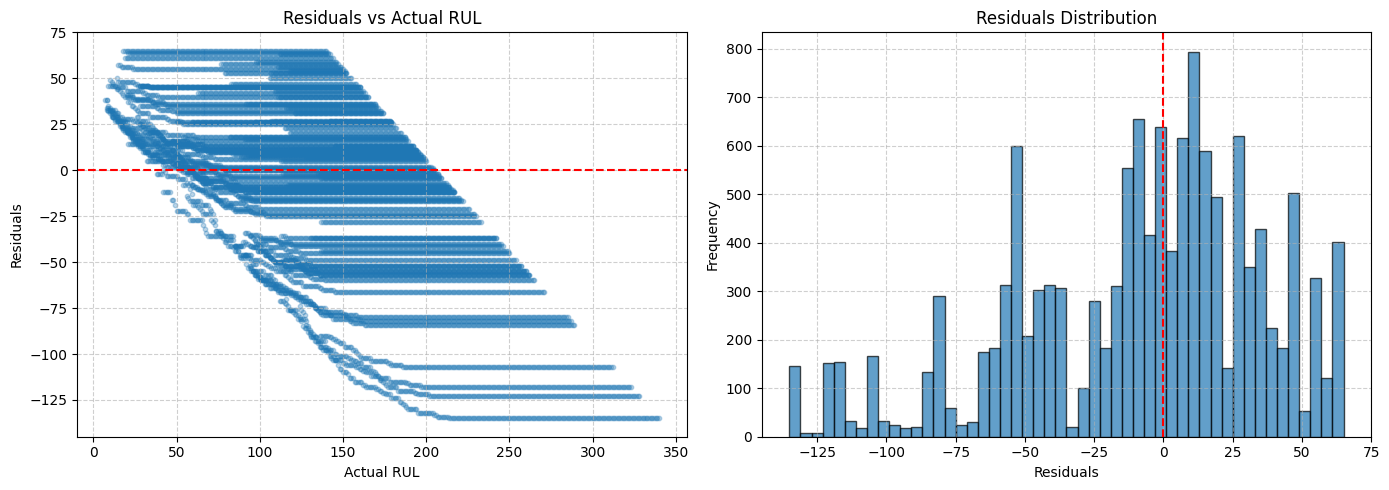

In [31]:
# Plot residuals distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Residuals vs Actual RUL (scatter with alpha)
residual = test_pred - test_data_copy['true_RUL']
axes[0].scatter(test_data_copy['true_RUL'], residual, alpha=0.3, s=10)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Actual RUL')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Actual RUL')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Right: Residuals Distribution (histogram)
axes[1].hist(residual, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

This gives us starting metrics scores (evaluated on the TEST data) that we will try to improve with ML models.

## Feature Selection

**What we do:** Identify and remove sensors that have constant values (standard deviation = 0) across all engine cycles. These sensors provide no useful information for predicting RUL.

**Why we do it:** 
- Constant sensors don't change over time, so they can't help predict degradation
- Removing them reduces dimensionality and speeds up model training
- We keep only sensors that actually vary and contain information about engine health

**Result:** We drop 4 constant sensors (sensor_1, sensor_10, sensor_18, sensor_19) and keep 17 active sensors for further analysis.

In [32]:
# Find constant sensors (std = 0)
constant_sensors = []
for col in [c for c in train_data.columns if 'sensor_' in c]:
    if train_data[col].std() == 0:
        constant_sensors.append(col)

print(f"Constant sensors to drop: {constant_sensors}")

# Drop them
train_data = train_data.drop(columns=constant_sensors)
test_data = test_data.drop(columns=constant_sensors)

Constant sensors to drop: ['sensor_1', 'sensor_10', 'sensor_18', 'sensor_19']


---

Constant sensors (0): []


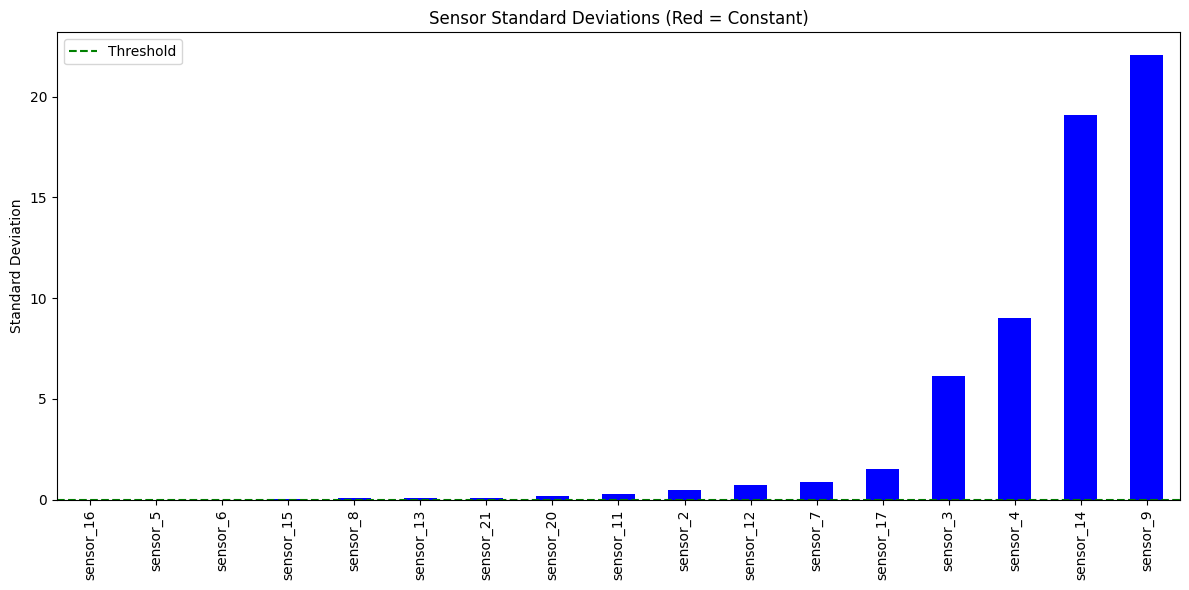

Dropped 0 constant sensors


In [33]:
# Find constant sensors
sensor_cols = [c for c in train_data.columns if 'sensor_' in c]
constant_sensors = [c for c in sensor_cols if train_data[c].std() == 0]

print(f"Constant sensors ({len(constant_sensors)}): {constant_sensors}")

# Plot sensor standard deviations
fig, ax = plt.subplots(figsize=(12, 6))
stds = train_data[sensor_cols].std().sort_values()
colors = ['red' if s in constant_sensors else 'blue' for s in stds.index]
stds.plot(kind='bar', color=colors, ax=ax)
ax.set_title('Sensor Standard Deviations (Red = Constant)')
ax.set_ylabel('Standard Deviation')
ax.axhline(y=0.001, color='green', linestyle='--', label='Threshold')
ax.legend()
plt.tight_layout()
plt.show()

# Drop constant sensors
train_data = train_data.drop(columns=constant_sensors)
test_data = test_data.drop(columns=constant_sensors)
print(f"Dropped {len(constant_sensors)} constant sensors")

## Normalization (Min-Max Scaling)

**What we do:** Scale all sensor values to a range of [0, 1] using Min-Max Scaler fitted on training data only.

**Why we do it:**
- Different sensors have different value ranges (e.g., sensor_2: 640-645 vs sensor_4: 1400-1440)
- Without scaling, models would unfairly prioritize sensors with larger magnitudes
- Normalization ensures all sensors contribute equally to the model
- It also speeds up convergence during model training

**Important:** We fit the scaler on training data only, then apply the same transformation to test data to prevent data leakage.

In [34]:
from sklearn.preprocessing import MinMaxScaler

# Fit on training data only
scaler = MinMaxScaler()
sensor_cols = [c for c in train_data.columns if 'sensor_' in c]

train_data[sensor_cols] = scaler.fit_transform(train_data[sensor_cols])
test_data[sensor_cols] = scaler.transform(test_data[sensor_cols])

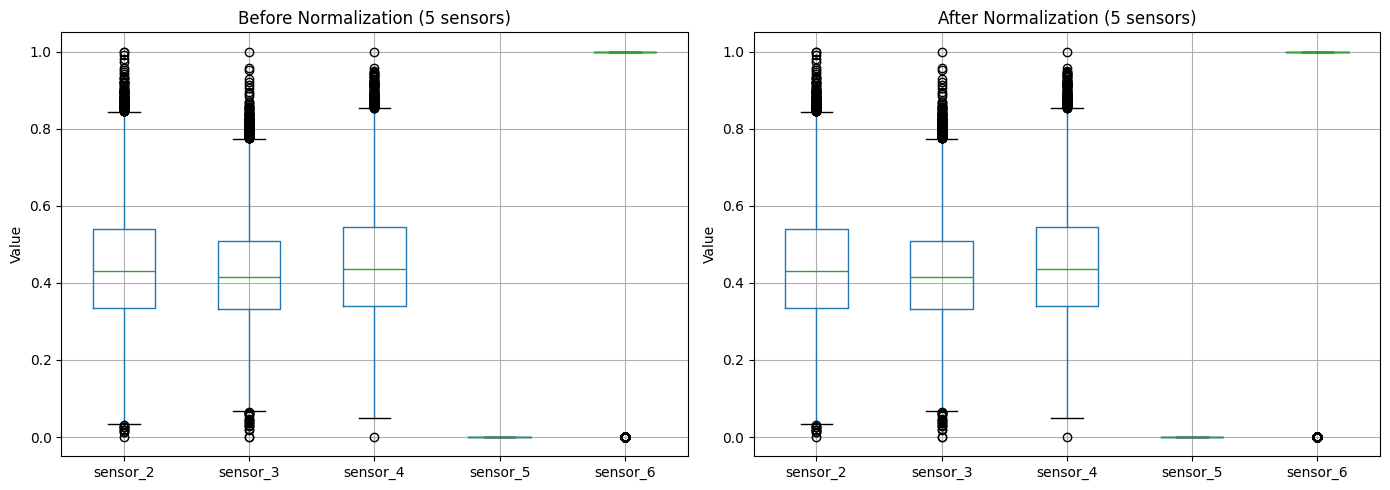

Scaler saved!


In [36]:
from sklearn.preprocessing import MinMaxScaler
import joblib
import os

# Before normalization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_data[sensor_cols[:5]].boxplot(ax=axes[0])
axes[0].set_title('Before Normalization (5 sensors)')
axes[0].set_ylabel('Value')

# Normalize
scaler = MinMaxScaler()
remaining_sensors = [c for c in train_data.columns if 'sensor_' in c]
train_data[remaining_sensors] = scaler.fit_transform(train_data[remaining_sensors])
test_data[remaining_sensors] = scaler.transform(test_data[remaining_sensors])

# After normalization
train_data[remaining_sensors[:5]].boxplot(ax=axes[1])
axes[1].set_title('After Normalization (5 sensors)')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

# Create models directory and save scaler
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')
print("Scaler saved!")

## Correlation Analysis with RUL

**What we do:** Calculate the correlation between each sensor and the target variable (RUL) to identify which sensors are most predictive of engine degradation.

**Why we do it:**
- Not all sensors are equally important for predicting RUL
- High correlation (positive or negative) indicates strong relationship with engine health
- We can focus on the most relevant sensors and potentially drop weak ones
- This improves model performance and reduces overfitting

**Interpretation:**
- Green bars (|correlation| &gt; 0.5): Strong predictors — most important sensors
- Orange bars (|correlation| &gt; 0.2): Moderate predictors — useful sensors
- Red bars (|correlation| &lt; 0.2): Weak predictors — may be dropped

**Result:** We identify 14 top-correlated sensors that will be used as primary features for our models.

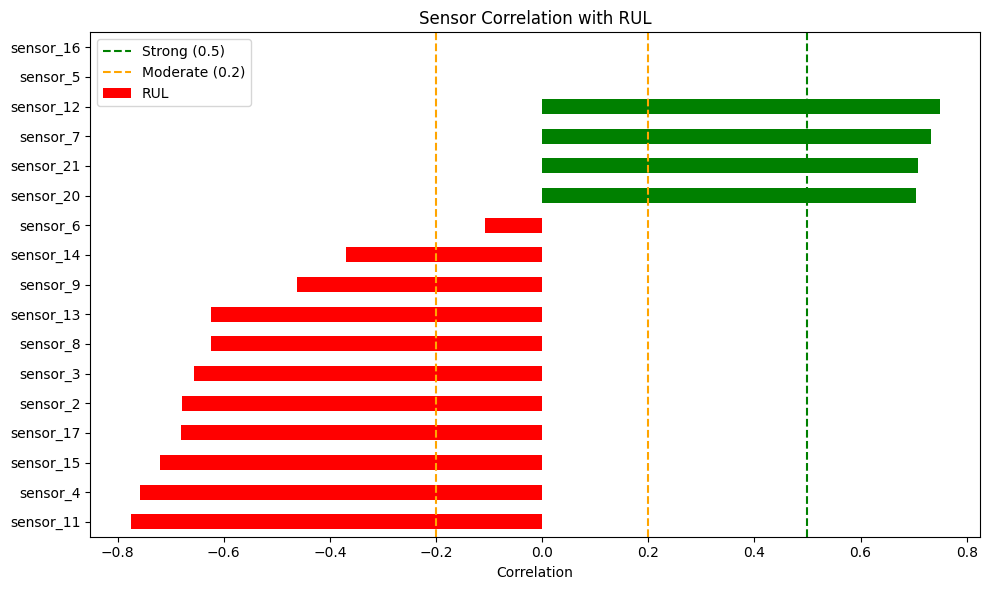

Top correlated sensors (14): ['sensor_11', 'sensor_4', 'sensor_15', 'sensor_17', 'sensor_2', 'sensor_3', 'sensor_8', 'sensor_13', 'sensor_9', 'sensor_14', 'sensor_20', 'sensor_21', 'sensor_7', 'sensor_12']


In [38]:
# Correlation with RUL
correlations = train_data[remaining_sensors + ['RUL']].corr()['RUL'].drop('RUL').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if c > 0.5 else 'orange' if c > 0.2 else 'red' for c in correlations]
correlations.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Sensor Correlation with RUL')
ax.set_xlabel('Correlation')
ax.axvline(x=0.5, color='green', linestyle='--', label='Strong (0.5)')
ax.axvline(x=0.2, color='orange', linestyle='--', label='Moderate (0.2)')
ax.axvline(x=-0.2, color='orange', linestyle='--')
ax.legend()
plt.tight_layout()
plt.show()

# Select top correlated sensors
top_sensors = correlations[correlations.abs() > 0.2].index.tolist()
print(f"Top correlated sensors ({len(top_sensors)}): {top_sensors}")

## Windowing / Sequence Generation

**What we do:** Convert the time-series data into fixed-length sequences (windows) of 30 time steps. Each sequence contains sensor readings from 30 consecutive cycles, and the target is the RUL at the end of the window.

**Why we do it:**
- Deep learning models (LSTM, Transformer) require sequential input, not single time points
- A window captures temporal patterns and trends in sensor degradation
- Using multiple consecutive cycles provides more context than a single snapshot
- This is essential for building predictive maintenance models that learn from historical patterns

**Parameters:**
- Window size: 30 cycles (captures ~1 month of operation)
- Stride: 1 (sliding window with step of 1 for maximum data utilization)

**Result:** We generate 19,331 sequences of shape (30, 17) for training deep learning models.

X_train shape: (17631, 30, 17)
y_train shape: (17631,)
Number of sequences: 17631
Window size: 30
Number of features: 17


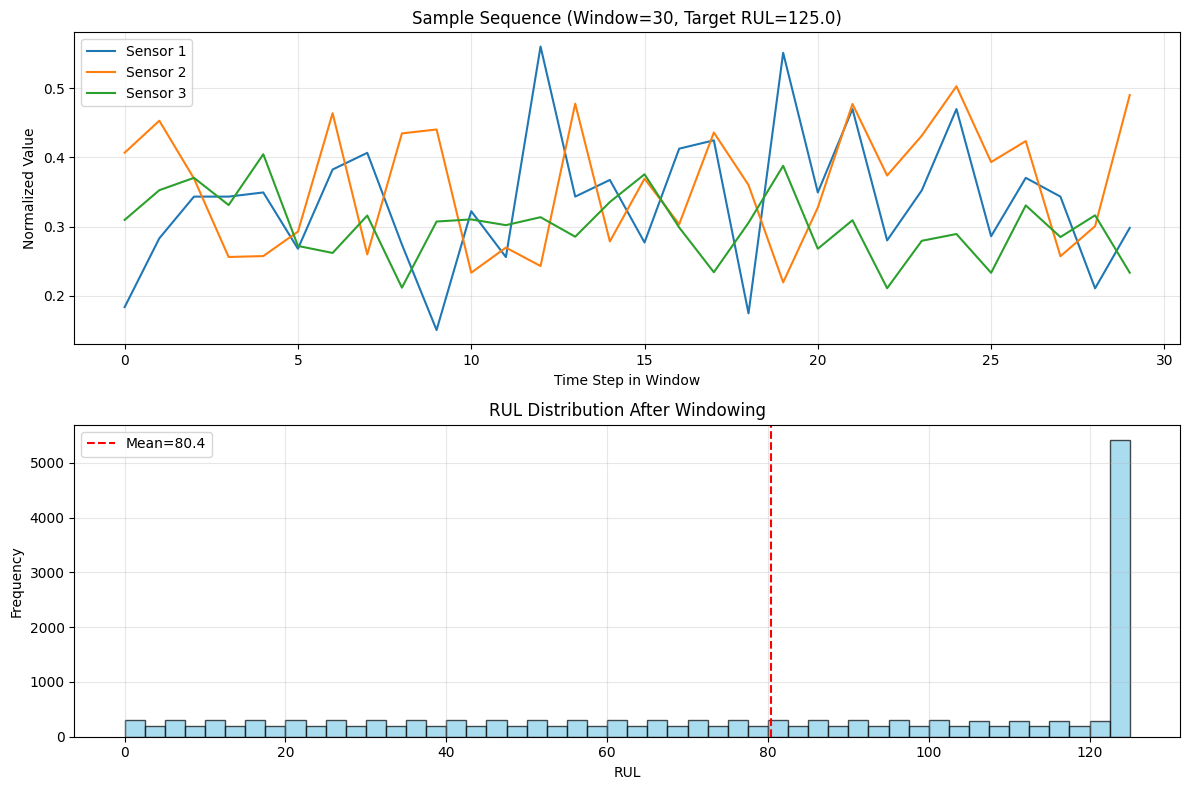

In [44]:
# Windowing / Sequence Generation

def create_sequences(data, window_size=30, stride=1):
    """
    Create sequences for LSTM/Transformer models.
    
    Parameters:
    -----------
    data : pd.DataFrame
        Preprocessed data with 'unit', 'time_cycles', sensors, 'RUL'
    window_size : int
        Number of time steps in each sequence
    stride : int
        Step size between sequences
    
    Returns:
    --------
    X : np.array
        Sequences of shape (samples, window_size, features)
    y : np.array
        Target RUL values
    """
    sequences = []
    targets = []
    
    # Use top correlated sensors only
    feature_cols = [c for c in data.columns if 'sensor_' in c]
    
    for unit in data['unit'].unique():
        unit_data = data[data['unit'] == unit].sort_values('time_cycles')
        
        # Skip if too short
        if len(unit_data) < window_size + 1:
            continue
        
        for i in range(0, len(unit_data) - window_size, stride):
            # Get window of features
            seq = unit_data.iloc[i:i+window_size][feature_cols].values
            # Get target (RUL at end of window)
            target = unit_data.iloc[i + window_size]['RUL']
            
            sequences.append(seq)
            targets.append(target)
    
    return np.array(sequences), np.array(targets)

# Create sequences
X_train, y_train = create_sequences(train_data, window_size=30, stride=1)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Number of sequences: {len(X_train)}")
print(f"Window size: {X_train.shape[1]}")
print(f"Number of features: {X_train.shape[2]}")

# Visualize one sequence
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot one window
sample_idx = 0  # First sequence
sample_seq = X_train[sample_idx]
sample_target = y_train[sample_idx]

# Plot first 3 sensors in the window
for i in range(min(3, sample_seq.shape[1])):
    axes[0].plot(sample_seq[:, i], label=f'Sensor {i+1}')

axes[0].set_title(f'Sample Sequence (Window=30, Target RUL={sample_target:.1f})')
axes[0].set_xlabel('Time Step in Window')
axes[0].set_ylabel('Normalized Value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot RUL distribution after windowing
axes[1].hist(y_train, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[1].set_title('RUL Distribution After Windowing')
axes[1].set_xlabel('RUL')
axes[1].set_ylabel('Frequency')
axes[1].axvline(x=y_train.mean(), color='red', linestyle='--', 
                label=f'Mean={y_train.mean():.1f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

import os
os.makedirs('../data', exist_ok=True)
np.save('../data/X_train_sequences.npy', X_train)
np.save('../data/y_train_sequences.npy', y_train)


## Save Preprocessed Data

**What we do:** Save all preprocessed datasets, generated sequences, and fitted scaler to disk for use in subsequent notebooks and model training.

**Why we do it:**
- Preprocessing is time-consuming; we don't want to repeat it every time
- Ensures consistency across different notebooks and team members
- The fitted scaler must be saved so we can apply the same transformation to new data during inference
- Sequences are large arrays; saving them as .npy files is efficient
- This creates a clean pipeline: raw data → preprocessing → saved artifacts → model training

**Saved artifacts:**
- `train_preprocessed.csv`: Training data after feature selection and normalization
- `test_preprocessed.csv`: Test data after feature selection and normalization
- `X_train_sequences.npy`: Windowed sequences for deep learning models
- `y_train_sequences.npy`: Target RUL values for each sequence
- `scaler.pkl`: Fitted MinMaxScaler for future data transformation

In [45]:
# Save preprocessed data for next notebooks
import os

# Create directories
os.makedirs('../data', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Save data
train_data.to_csv('../data/train_preprocessed.csv', index=False)
test_data.to_csv('../data/test_preprocessed.csv', index=False)

# Save sequences
np.save('../data/X_train_sequences.npy', X_train)
np.save('../data/y_train_sequences.npy', y_train)

# Save scaler
joblib.dump(scaler, '../models/scaler.pkl')

print("Files saved:")
print("  - ../data/train_preprocessed.csv")
print("  - ../data/test_preprocessed.csv")
print("  - ../data/X_train_sequences.npy")
print("  - ../data/y_train_sequences.npy")
print("  - ../models/scaler.pkl")

Files saved:
  - ../data/train_preprocessed.csv
  - ../data/test_preprocessed.csv
  - ../data/X_train_sequences.npy
  - ../data/y_train_sequences.npy
  - ../models/scaler.pkl
